# 4.6 直流回路

- 4.6.1 抵抗の接続
- 4.6.2 電池の起電力と内部抵抗
- 4.6.3 電流計と電圧計
- **4.6.4 キルヒホッフの法則**

In [ ]:
#@title おまじない
! pip -qqq install schemdraw
#! pip show schemdraw
! pip -qqq install ziamath

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import schemdraw
import schemdraw.elements as elm

schemdraw.config(font='cmb10')
#elm.style(elm.STYLE_IEC) # IEC/European style
elm.style(elm.STYLE_IEEE) # IEEE style

#schemdraw.config(mathfont='cm')
#import matplotlib.pyplot as plt
#plt.xkcd()

## 物理量の数値と単位の抽出方法

- 電流 $I = 5~{\rm A}$ としたとき
  - 電流の数値を $\{I\}=5$
  - 電流の単位を $[I]={\rm A}$

- 電圧 $V = 100~{\rm V}$ としたとき
  - 電流の数値を $\{V\}=100$
  - 電流の単位を $[V]={\rm V}$

- 抵抗 $R = 80~{\rm \Omega}$ としたとき
  - 電流の数値を $\{R\}=80$
  - 電流の単位を $[R]={\rm \Omega}$  

で取り出すこととする。

---
ref.
https://www.jstage.jst.go.jp/article/peu/25/1/25_2/_article/-char/ja/

## 4.6.4 キルヒホッフの法則

[Gustav Kirchhoff](https://en.wikipedia.org/wiki/Gustav_Kirchhoff) は、
[Ohm's law](https://en.wikipedia.org/wiki/Ohm%27s_law) を電気回路網に拡張し、次の二つの定理をまとめた。

## 第一法則

### 電流則

実は電圧計を議論するときに使っています。

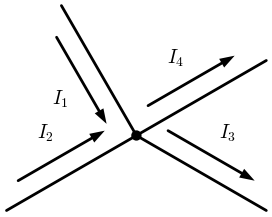

In [ ]:
# @title Kirchhoff's current law(KCL)
with schemdraw.Drawing(mathfont='cm') as d:
  L1=elm.Line().theta(30)
  elm.Dot()
  d.push()
  L2=elm.Line().theta(30)
  d.pop()
  d.push()
  L3=elm.Line().theta(-30)
  d.pop()
  L4=elm.Line().theta(120)
  elm.CurrentLabel(top=True, ofst=0.4, ).at(L1).label('$I_2$')
  elm.CurrentLabel(top=True, ofst=0.4,  l=d.unit*1.8).at(L2).label('$I_4$')
  elm.CurrentLabel(top=True, ofst=0.4, ).at(L3).label('$I_3$')
  elm.CurrentLabel(top=True, ofst=0.4, reverse=True).at(L4).label('$I_1$')

\begin{align*}
I_1 + I_2 &= I_3 + I_4
\end{align*}

> 回路網の任意の接続点へ向かって流入する電流の総和と、  
その接続点から流出する電流の総和は等しい


見方を変えると
\begin{align*}
I_1 + I_2 &= I_3 + I_4\\[1mm]
&I_1 + I_2 + (-I_3) + (-I_4) =0 \\[1mm]
&\color{red}{I'_1} + \color{red}{I'_2}
 + \color{blue}{I'_3} + \color{blue}{I'_4} = 0 \\[2mm]
 \sum_{k=1}^{4} I'_k &=0
\end{align*}

> 回路網の任意の接続点に注目し、  
そこへ流入する(正の)電流と流出する(負の)電流の総和は  
ゼロになる

## 第二法則

### 電圧則

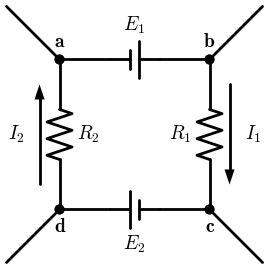

In [ ]:
# @title Kirchhoff's voltage law(KVL)
with schemdraw.Drawing(mathfont='cm') as d:
  elm.Line(l=d.unit*1/2).theta(-45)
  elm.Dot().label("a")
  d.push()
  elm.Line(l=d.unit*1/3).theta(0)
  E1=elm.BatteryCell(l=d.unit*1/3).reverse().theta(0).label("$E_1$",loc="top")
  elm.Line(l=d.unit*1/3).theta(0)
  d.pop()
  elm.Line(l=d.unit*1/3).theta(-90)
  R2=elm.Resistor(l=d.unit*1/3).theta(-90).label("$R_2$",loc="bot")
  elm.Line(l=d.unit*1/3).theta(-90)
  d.push()
  elm.Dot().label("d",loc="bot")
  elm.Line(l=d.unit*1/2).theta(-135)
  d.pop()
  elm.Line(l=d.unit*1/3).theta(0)
  E2=elm.BatteryCell(l=d.unit*1/3).theta(0).label("$E_2$",loc="bot")
  elm.Line(l=d.unit*1/3).theta(0)
  d.push()
  elm.Dot().label("c", loc="bot")
  elm.Line(l=d.unit*1/3).theta(90)
  R1=elm.Resistor(l=d.unit*1/3).theta(90).label("$R_1$")
  elm.Line(l=d.unit*1/3).theta(90)
  elm.Dot().label("b")
  elm.Line(l=d.unit*1/2).theta(45)
  d.pop()
  elm.Line(l=d.unit*1/2).theta(-45)
  elm.CurrentLabel(top=False, ofs=.3, reverse=True).at(R2).label('$I_2$',loc="top")
  elm.CurrentLabel(top=False, ofs=.3, reverse=True).at(R1).label('$I_1$',loc="bot")

経路 a $\to$ b $\to$ c $\to$ d ($\to$a )   
[上図では a から出発し時計回り]
\begin{align*}
E_1 + E_2 = R_1\, I_1 + R_2\, I_2
\end{align*}

> 電気回路網に閉じた(方向を有する)経路を考慮したとき、  
その経路に沿った起電力(電力上昇)の総和と、  
同じ経路上の抵抗(等)による電圧降下の総和は、等しくなる。

- 選択した経路の方向と同じ向きに電位が大きくなるとき正の起電力
  - 逆であれば負の起電力
- 選択した経路の方向と同じ向きに進んだときに、  
電圧降下が起こる時は、正の電圧降下
  - 逆であれば負の電圧降下

見方を変えると
\begin{align*}
E_1 + E_2 = R_1\, I_1 + R_2\, I_2\\[1mm]
E_1 + E_2 + (- R_1\, I_1) + (- R_2\, I_2) =0
\end{align*}

> 一周回って戻ったら、電圧上昇と降下を経て、  
 出発時点の元の電圧になる。  
 つまり電圧変化はゼロ

 と表現できる